<a href="https://colab.research.google.com/github/agupta7654/ml/blob/main/Amazon_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow_datasets as tfds
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_df = pd.read_csv('/content/drive/MyDrive/Junior Research Project/Sentiment Analysis/train.csv', names=['rating', 'header', 'body'])
test_df = pd.read_csv('/content/drive/MyDrive/Junior Research Project/Sentiment Analysis/test.csv', names=['rating', 'header', 'body'])

In [ ]:
train_df['rating'] -= 1
test_df['rating'] -= 1

In [ ]:
train_df

,rating,header,body
0,1,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,1,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,1,Amazing!,This soundtrack is my favorite music of all ti...
3,1,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,1,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."
...,...,...,...
3599995,0,Don't do it!!,The high chair looks great when it first comes...
3599996,0,"Looks nice, low functionality",I have used this highchair for 2 kids now and ...
3599997,0,"compact, but hard to clean","We have a small house, and really wanted two o..."
3599998,0,what is it saying?,not sure what this book is supposed to be. It ...


In [ ]:
raw_train = tf.data.Dataset.from_tensor_slices((train_df['body'].values, train_df['rating'].values))
raw_test = tf.data.Dataset.from_tensor_slices((test_df['body'].values, test_df['rating'].values))

tf.random.set_seed(42)
train_set = raw_train.take(20000).shuffle(5000, seed=42).batch(512).prefetch(1)
test_set = raw_test.take(20000).batch(512).prefetch(1)

In [ ]:
for review, label in raw_train.take(10):
    print(review.numpy().decode('utf-8'))
    print(label.numpy())

This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
1
I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.
1
This soundtrack is my favorite music of all time, hands down. The intense sadness of "Prisoners of Fate" (which means all the more

In [ ]:
mini_train = train_set.take(20000)
mini_test = test_set.take(20000)

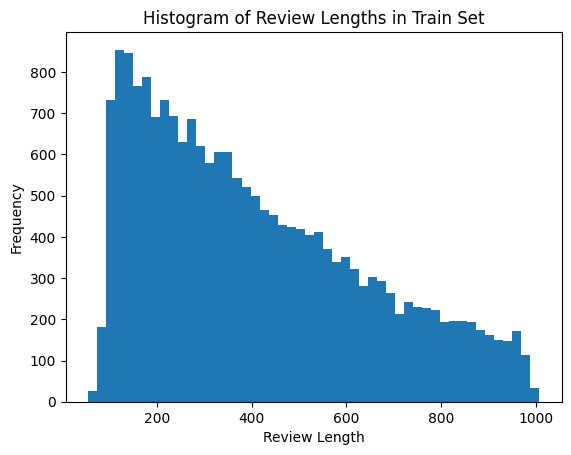

In [ ]:
review_lengths = []
for review, _ in raw_train.take(20000):
  review_lengths.append(len(review.numpy()))

plt.hist(review_lengths, bins=50)
plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Histogram of Review Lengths in Train Set")
plt.show()


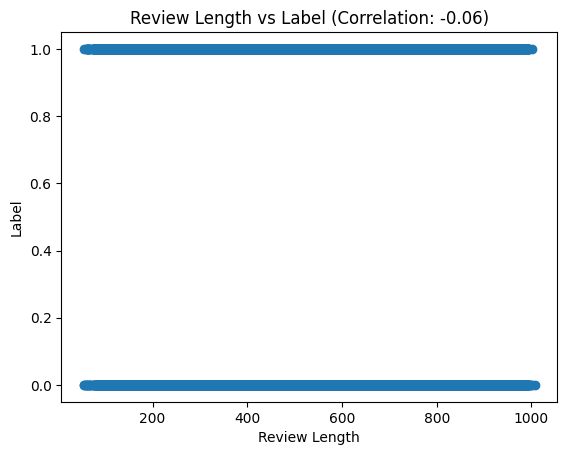

Correlation between review length and label: -0.06


In [ ]:
import numpy as np

review_lengths = []
labels = []
for review, label in raw_train.take(20000):
  review_lengths.append(len(review.numpy()))
  labels.append(label.numpy())

# Calculate correlation
correlation = np.corrcoef(review_lengths, labels)[0, 1]

# Plot review length vs label
plt.scatter(review_lengths, labels)
plt.xlabel("Review Length")
plt.ylabel("Label")
plt.title(f"Review Length vs Label (Correlation: {correlation:.2f})")
plt.show()

print(f"Correlation between review length and label: {correlation:.2f}")


In [ ]:
vocab_size = 5000
if True:
  text_vec_layer = tf.keras.layers.TextVectorization(
      max_tokens=vocab_size,
      output_mode="int",
  )
  text_vec_layer.adapt(train_df['body'][:20000])
    # Create model to save TextVectorization Layer
  model = tf.keras.models.Sequential()
  model.add(tf.keras.Input(shape=(1,), dtype=tf.string))
  model.add(text_vec_layer)

  # Save.
  filepath = "/content/drive/MyDrive/Junior Research Project/Sentiment Analysis/TextVecLayer-Amazon.keras"
  model.save(filepath)

In [ ]:
filepath = "/content/drive/MyDrive/Junior Research Project/Sentiment Analysis/TextVecLayer-Amazon.keras"
loaded_model = tf.keras.models.load_model(filepath)
text_vec_layer = loaded_model.layers[0]

In [ ]:
import os, datetime
vocab_size = 5000
embed_size = 256
if True:
  model = tf.keras.Sequential([
      text_vec_layer,
      tf.keras.layers.Embedding(vocab_size, embed_size, mask_zero=True),
      tf.keras.layers.GRU(256),
      tf.keras.layers.Dropout(0.3),
      tf.keras.layers.Dense(1, activation="sigmoid")
  ])

  model.compile(loss="binary_crossentropy", optimizer="nadam", metrics=["accuracy"])
  # history = model.fit(train_set, epochs=2)

  # Define file path for saving the best model
  model_save_path = "/content/drive/MyDrive/Junior Research Project/Sentiment Analysis/best_model.h5"

  early_stopping = EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)

  # Callback to save the model only when validation accuracy improves
  checkpoint_callback = ModelCheckpoint(
      model_save_path,  # File path
      monitor='loss',  # Monitor validation accuracy
      save_best_only=True,  # Save only when it improves
      mode='min',  # Higher accuracy is better
      verbose=0  # Print when model is saved
  )

  # Train model with validation and checkpoint callback
  history = model.fit(
      train_set,
      epochs=15,
      callbacks=[checkpoint_callback, early_stopping]
  )


Epoch 1/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.5627 - loss: 0.7479

40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.5638 - loss: 0.7473
Epoch 2/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7230 - loss: 0.5673

40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 0.7236 - loss: 0.5662
Epoch 3/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8435 - loss: 0.3618

40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - accuracy: 0.8438 - loss: 0.3611
Epoch 4/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8913 - loss: 0.2698

40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 150ms/step - accuracy: 0.8914 - loss: 0.2698
Epoch 5/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9079 - loss: 0.2363

...

40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.9559 - loss: 0.1282
Epoch 11/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9668 - loss: 0.1067

40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 191ms/step - accuracy: 0.9668 - loss: 0.1066
Epoch 12/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9724 - loss: 0.0915

40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.9724 - loss: 0.0915
Epoch 13/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9738 - loss: 0.0835

40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 163ms/step - accuracy: 0.9739 - loss: 0.0834
Epoch 14/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 164ms/step - accuracy: 0.9585 - loss: 0.1113
Epoch 15/15
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9813 - loss: 0.0621

40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step - accuracy: 0.9814 - loss: 0.0621


In [ ]:
# from tensorflow.keras.models import load_model
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# tf.config.run_functions_eagerly(True)
# # Define file path for the saved model
# model_save_path = "/content/drive/MyDrive/Junior Research Project/Sentiment Analysis/best_model.h5"

# # Load the previously saved model
# model = load_model(model_save_path)

# # Callback to save the model when validation accuracy improves
# checkpoint_callback = ModelCheckpoint(
#     model_save_path,  # Save to the same file
#     monitor='loss',
#     save_best_only=True,
#     mode='min',
#     verbose=0
# )

# # Early stopping to prevent overfitting
# early_stopping = EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)

# # Continue training for more epochs
# history = model.fit(
#     train_set,  # Use the same training set
#     epochs=10,  # Continue training for 10 more epochs
#     callbacks=[checkpoint_callback, early_stopping]
# )

In [ ]:
import numpy as np

# Get true labels (y) for the entire test set
y_true = []
for batch in test_set:
    _, y_batch = batch  # Only take labels (ignore X with `_`)
    y_true.append(y_batch.numpy())  # Convert to NumPy
y_true = np.concatenate(y_true)  # Combine all batches into one array

# Get predictions from the model for the entire test set
classifications = model.predict(test_set)



40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step


In [ ]:
classifications = (classifications.flatten() > 0.5).astype(int)  # Convert predictions to binary values (0 or 1)
# print(classifications)

# Calculate accuracy
accuracy = np.mean(classifications == y_true)
# print(y_true)
print(f"Accuracy: {accuracy * 100:.2f}%")


# Identify misclassified instances
misclassified_indices = np.where(classifications != y_true)[0]  # Get indices of misclassifications

# Print some misclassified inputs
misclassified_X = []  # List to store misclassified inputs
for idx in misclassified_indices[:5]:  # Print up to 5 misclassified examples
    for batch in test_set.take(1):  # Get the first batch
        X_batch, _ = batch  # Get the input features (X)
        misclassified_X.append(X_batch[idx].numpy())  # Append the misclassified input (X)
        break

# Print some misclassified X values along with true labels and predictions
for i, idx in enumerate(misclassified_indices[:5]):
    print(f"Misclassified Sample {i+1}:")
    print(f"True Label: {y_true[idx]}")
    print(f"Predicted: {classifications[idx]}")
    print(f"Misclassified Input (X): {misclassified_X[i]}")
    print("-" * 50)

Accuracy: 82.36%
Misclassified Sample 1:
True Label: 1
Predicted: 0
Misclassified Input (X): b"Check out Maha Energy's website. Their Powerex MH-C204F charger works in 100 minutes for rapid charge, with option for slower charge (better for batteries). And they have 2200 mAh batteries."
--------------------------------------------------
Misclassified Sample 2:
True Label: 0
Predicted: 1
Misclassified Input (X): b"I cannot scroll through a DVD menu that is set up vertically. The triangle keys will only select horizontally. So I cannot select anything on most DVD's besides play. No special features, no language select, nothing, just play."
--------------------------------------------------
Misclassified Sample 3:
True Label: 0
Predicted: 1
Misclassified Input (X): b'If you want to listen to El Duke , then it is better if you have access to his shower,this is not him, it is a gimmick,very well orchestrated.'
--------------------------------------------------
Misclassified Sample 4:
True La

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step


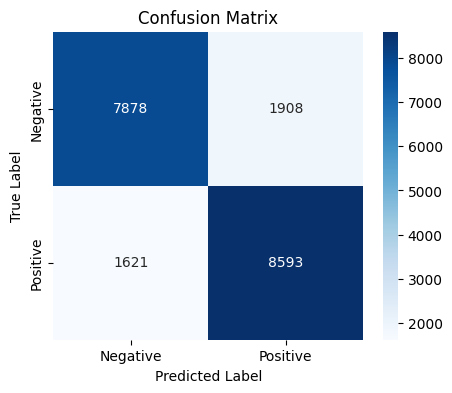

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Get true labels from test set
y_true = []
for batch in test_set:
    _, y_batch = batch  # Only take labels (ignore X with `_`)
    y_true.append(y_batch.numpy())  # Convert to NumPy
y_true = np.concatenate(y_true)  # Combine all batches into one array

# Get predictions from the model
y_pred = model.predict(test_set)
y_pred = (y_pred.flatten() > 0.5).astype(int)  # Convert to binary (0 or 1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()